# Ola Driver Attrition Analysis

## Executive Summary
This project analyzes Ola driver attrition using historical driver data. The objective is to identify the key factors influencing attrition and provide actionable business recommendations to improve driver retention.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Business Problem
Recruiting and retaining drivers is a major challenge for Ola. High driver attrition increases hiring costs, affects operational efficiency, and impacts business performance.

## Project Objectives
- Understand the dataset
- Clean and preprocess the data
- Perform feature engineering
- Conduct exploratory data analysis
- Identify factors affecting attrition
- Provide business recommendations

## Data Dictionary
| Column | Description |
|---|---|
| Driver_ID | Unique Driver Identifier |
| Age | Driver Age |
| Gender | Driver Gender |
| Income | Monthly Income |
| Quarterly Rating | Driver Performance |
| Total Business Value | Business Generated |
| LastWorkingDate | Driver Exit Date |

# Import Required Libraries

In [1]:
# Import Required Libraries

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Load Dataset

In [2]:
# Load Dataset

df = pd.read_csv("../data/ola_driver.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# Data Understanding

In [3]:
# Dataset Overview

df.head()

df.tail()

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.columns

df.info()

# Data Types
df.dtypes

Rows : 19104
Columns : 14
<class 'pandas.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  str    
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  str    
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  str    
 9   LastWorkingDate       1616 non-null   str    
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), str(4)
memory usage: 2.0 MB


Unnamed: 0                int64
MMM-YY                      str
Driver_ID                 int64
Age                     float64
Gender                  float64
City                        str
Education_Level           int64
Income                    int64
Dateofjoining               str
LastWorkingDate             str
Joining Designation       int64
Grade                     int64
Total Business Value      int64
Quarterly Rating          int64
dtype: object

In [4]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,19104.0,9551.500000,5.514994e+03,0.0,4775.75,9551.5,14327.25,19103.0
Driver_ID,19104.0,1415.591133,8.107053e+02,1.0,710.00,1417.0,2137.00,2788.0
Age,19043.0,34.668435,6.257912e+00,21.0,30.00,34.0,39.00,58.0
Gender,19052.0,0.418749,4.933670e-01,0.0,0.00,0.0,1.00,1.0
Education_Level,19104.0,1.021671,8.001671e-01,0.0,0.00,1.0,2.00,2.0
Income,19104.0,65652.025126,3.091452e+04,10747.0,42383.00,60087.0,83969.00,188418.0
Joining Designation,19104.0,1.690536,8.369837e-01,1.0,1.00,1.0,2.00,5.0
Grade,19104.0,2.252670,1.026512e+00,1.0,1.00,2.0,3.00,5.0
Total Business Value,19104.0,571662.074958,1.128312e+06,-6000000.0,0.00,250000.0,699700.00,33747720.0
Quarterly Rating,19104.0,2.008899,1.009832e+00,1.0,1.00,2.0,3.00,4.0


In [5]:
# Missing Values
df.isnull().sum()

Unnamed: 0                  0
MMM-YY                      0
Driver_ID                   0
Age                        61
Gender                     52
City                        0
Education_Level             0
Income                      0
Dateofjoining               0
LastWorkingDate         17488
Joining Designation         0
Grade                       0
Total Business Value        0
Quarterly Rating            0
dtype: int64

In [6]:
# Missing Value Percentage


missing = pd.DataFrame({
    "Missing Values":df.isnull().sum(),
    "Percentage":round(df.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage
Unnamed: 0,0,0.00
MMM-YY,0,0.00
Driver_ID,0,0.00
Age,61,0.32
Gender,52,0.27
City,0,0.00
Education_Level,0,0.00
Income,0,0.00
Dateofjoining,0,0.00
LastWorkingDate,17488,91.54


In [7]:
# Duplicate Records
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [8]:
# Unique Drivers
df["Driver_ID"].nunique()

2381

In [9]:
# Convert Date Columns
date_columns=["MMM-YY","Dateofjoining","LastWorkingDate"]

for col in date_columns:
    df[col]=pd.to_datetime(df[col])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Unnamed: 0            19104 non-null  int64         
 1   MMM-YY                19104 non-null  datetime64[us]
 2   Driver_ID             19104 non-null  int64         
 3   Age                   19043 non-null  float64       
 4   Gender                19052 non-null  float64       
 5   City                  19104 non-null  str           
 6   Education_Level       19104 non-null  int64         
 7   Income                19104 non-null  int64         
 8   Dateofjoining         19104 non-null  datetime64[us]
 9   LastWorkingDate       1616 non-null   datetime64[us]
 10  Joining Designation   19104 non-null  int64         
 11  Grade                 19104 non-null  int64         
 12  Total Business Value  19104 non-null  int64         
 13  Quarterly Rating      19104

# Data Cleaning & Preprocessing

In this section, we will:
- Check and handle missing values
- Convert data types where required
- Analyze duplicate records
- Prepare the dataset for further analysis

In [10]:
# Missing Values Count

missing = df.isnull().sum().sort_values(ascending=False)

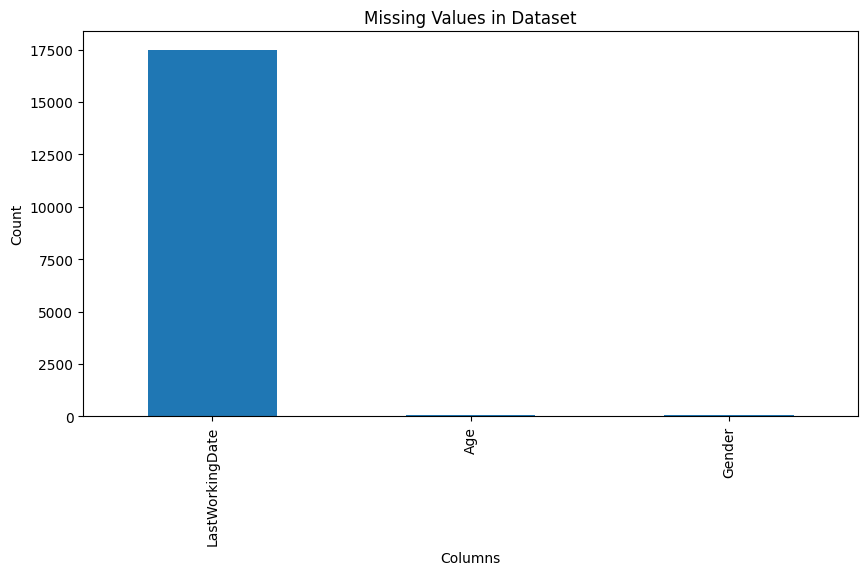

In [11]:
# Missing Value Visualization
plt.figure(figsize=(10,5))

missing[missing>0].plot(kind='bar')

plt.title("Missing Values in Dataset")
plt.ylabel("Count")
plt.xlabel("Columns")
plt.savefig("../images/missing_value_Dataset.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- LastWorkingDate contains missing values.
- Missing values in LastWorkingDate indicate that the driver is still active.
- Other columns contain very few or no missing values.

In [12]:
# Check Duplicate Driver Records


df["Driver_ID"].value_counts().head(10)

# Driver Count

print("Total Records :",len(df))
print("Unique Drivers :",df["Driver_ID"].nunique())

Total Records : 19104
Unique Drivers : 2381


### Observation

Each driver appears multiple times because the dataset contains monthly records.

In [13]:
# Target Variable (Attrition)

df["Attrition"] = np.where(df["LastWorkingDate"].isnull(),0,1)

# 0 → Active Driver
# 1 → Left Ola

df["Attrition"].value_counts()

Attrition
0    17488
1     1616
Name: count, dtype: int64

In [14]:
# Attrition Percentage

attrition = round(df["Attrition"].value_counts(normalize=True)*100,2)

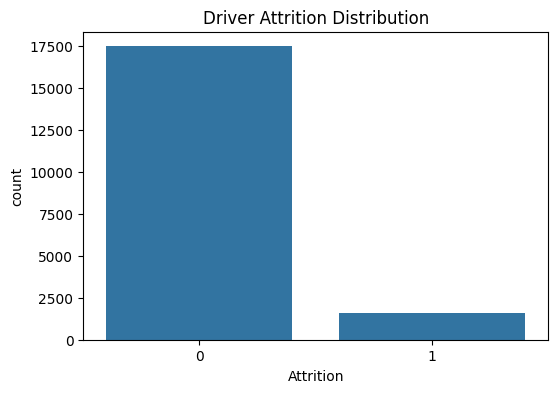

In [15]:
# Attrition Chart

plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Attrition")
plt.title("Driver Attrition Distribution")
plt.savefig("../images/driver_attrition_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Feature Engineering

## Overview

Feature engineering is the process of creating meaningful variables from existing data. These features help uncover patterns, improve analysis, and support better business decisions.

In this section, we will:

- Create the Attrition target variable
- Calculate driver tenure
- Track income growth
- Track quarterly rating improvement
- Create driver-level dataset

In [16]:
# Sort Dataset
df = df.sort_values(["Driver_ID","MMM-YY"])


In [17]:
# Driver Level Dataset

driver_df = df.groupby("Driver_ID").last().reset_index()

driver_df.head()



,Driver_ID,Unnamed: 0,MMM-YY,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Attrition
0,1,2,2019-03-01,28.0,0.0,C23,2,57387,2018-12-24,2019-03-11,1,1,0,2,1
1,2,4,2020-12-01,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1,0
2,4,9,2020-04-01,43.0,0.0,C13,2,65603,2019-12-07,2020-04-27,2,2,0,1,1
3,5,12,2019-03-01,29.0,0.0,C9,0,46368,2019-01-09,2019-03-07,1,1,0,1,1
4,6,17,2020-12-01,31.0,1.0,C11,1,78728,2020-07-31,NaT,3,3,0,2,0


In [18]:
# Shape
print(driver_df.shape)

(2381, 15)


In [19]:
# Attrition Distribution

driver_df["Attrition"].value_counts()



Attrition
1    1616
0     765
Name: count, dtype: int64

In [20]:
# Attrition %
round(driver_df["Attrition"].value_counts(normalize=True)*100,2)


Attrition
1    67.87
0    32.13
Name: proportion, dtype: float64

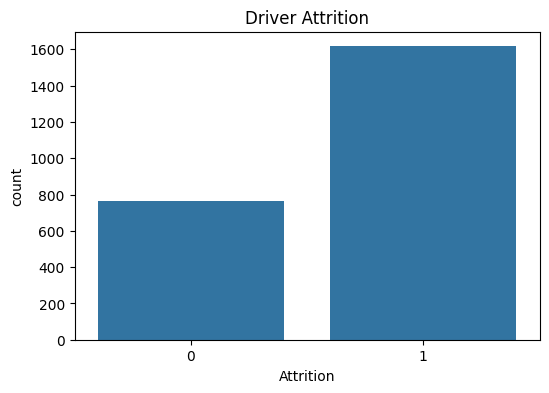

In [21]:
# Attrition Graph

plt.figure(figsize=(6,4))
sns.countplot(data=driver_df,x="Attrition")
plt.title("Driver Attrition")
plt.savefig("../images/driver_attrition.png", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
# Attrition Distribution

driver_df["Attrition"].value_counts()

Attrition
1    1616
0     765
Name: count, dtype: int64

In [23]:
# Attrition %

round(driver_df["Attrition"].value_counts(normalize=True)*100,2)


Attrition
1    67.87
0    32.13
Name: proportion, dtype: float64

## Driver Tenure

Driver tenure represents the total duration (in days) that a driver remained associated with Ola. It is calculated using the Date of Joining and Last Working Date.

For active drivers (where LastWorkingDate is missing), the latest reporting date is considered as the end date.

In [24]:
# Create End Date

driver_df["End_Date"] = driver_df["LastWorkingDate"]

driver_df["End_Date"] = driver_df["End_Date"].fillna(driver_df["MMM-YY"])

# Calculate Tenure

driver_df["Tenure_Days"] = (
    driver_df["End_Date"] - driver_df["Dateofjoining"]
).dt.days

driver_df[["Driver_ID", "Dateofjoining", "End_Date", "Tenure_Days"]].head()

,Driver_ID,Dateofjoining,End_Date,Tenure_Days
0,1,2018-12-24,2019-03-11,77
1,2,2020-11-06,2020-12-01,25
2,4,2019-12-07,2020-04-27,142
3,5,2019-01-09,2019-03-07,57
4,6,2020-07-31,2020-12-01,123


In [25]:
# Convert into Months
driver_df["Tenure_Months"] = round(driver_df["Tenure_Days"] / 30, 1)

driver_df[["Tenure_Days", "Tenure_Months"]].head()

,Tenure_Days,Tenure_Months
0,77,2.6
1,25,0.8
2,142,4.7
3,57,1.9
4,123,4.1


### Observation

- Driver tenure has been calculated using the joining date and end date.
- For active drivers, the latest reporting month has been considered as the end date.
- Tenure will help analyze whether new drivers are more likely to leave the company.

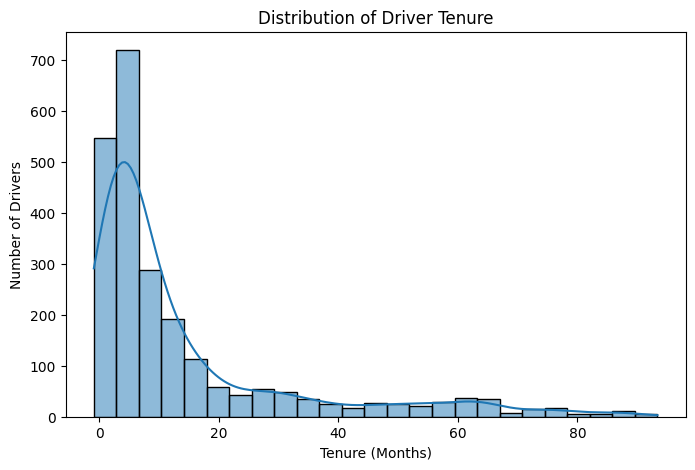

In [26]:
# Driver Tenure Distribution

plt.figure(figsize=(8,5))
sns.histplot(driver_df["Tenure_Months"], bins=25, kde=True)
plt.title("Distribution of Driver Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Drivers")
plt.savefig("../images/distribution_driver_tenure.png", dpi=300, bbox_inches="tight")

plt.show()

In [27]:
# Summary Statistics
driver_df["Tenure_Months"].describe()

count    2381.000000
mean       14.150987
std        18.814224
min        -0.900000
25%         3.000000
50%         6.000000
75%        15.600000
max        93.400000
Name: Tenure_Months, dtype: float64

## Income Growth Analysis

To analyze salary progression, we compare the first recorded income with the last recorded income for each driver.

A new feature **Income_Increased** is created:

- **1** → Income increased
- **0** → Income remained the same or decreased

This feature helps identify whether income growth influences driver retention.

In [28]:
# First Income of each driver
first_income = df.groupby("Driver_ID")["Income"].first()

# Last Income of each driver
last_income = df.groupby("Driver_ID")["Income"].last()

# Map values
driver_df["First_Income"] = driver_df["Driver_ID"].map(first_income)
driver_df["Last_Income"] = driver_df["Driver_ID"].map(last_income)

# Income Increased Feature
driver_df["Income_Increased"] = np.where(
    driver_df["Last_Income"] > driver_df["First_Income"], 1, 0
)

driver_df[["Driver_ID", "First_Income", "Last_Income", "Income_Increased"]].head()

,Driver_ID,First_Income,Last_Income,Income_Increased
0,1,57387,57387,0
1,2,67016,67016,0
2,4,65603,65603,0
3,5,46368,46368,0
4,6,78728,78728,0


### Observation

- Income growth has been tracked for every driver.
- Drivers whose latest income is higher than their initial income are marked as **1**.
- This feature will help determine whether salary growth has an impact on attrition.

## Quarterly Rating Improvement

Driver performance is evaluated using the quarterly rating.

A new feature **Quarterly_Rating_Increased** is created:

- **1** → Rating improved
- **0** → Rating remained the same or decreased

This helps analyze whether performance improvement is associated with better driver retention.

In [29]:
# First Rating
first_rating = df.groupby("Driver_ID")["Quarterly Rating"].first()

# Last Rating
last_rating = df.groupby("Driver_ID")["Quarterly Rating"].last()

driver_df["First_Rating"] = driver_df["Driver_ID"].map(first_rating)
driver_df["Last_Rating"] = driver_df["Driver_ID"].map(last_rating)

driver_df["Quarterly_Rating_Increased"] = np.where(
    driver_df["Last_Rating"] > driver_df["First_Rating"], 1, 0
)

driver_df[
    [
        "Driver_ID",
        "First_Rating",
        "Last_Rating",
        "Quarterly_Rating_Increased",
    ]
].head()

,Driver_ID,First_Rating,Last_Rating,Quarterly_Rating_Increased
0,1,2,2,0
1,2,1,1,0
2,4,1,1,0
3,5,1,1,0
4,6,1,2,1


### Observation

- Quarterly ratings have been compared between the first and last records of each driver.
- Drivers with improved ratings are labeled as **1**.
- This feature will help analyze the relationship between performance improvement and driver attrition.

In [30]:
# Verify New Features
driver_df[
    [
        "Tenure_Months",
        "Income_Increased",
        "Quarterly_Rating_Increased",
        "Attrition",
    ]
].head()

,Tenure_Months,Income_Increased,Quarterly_Rating_Increased,Attrition
0,2.6,0,0,1
1,0.8,0,0,0
2,4.7,0,0,1
3,1.9,0,0,1
4,4.1,0,1,0


# Exploratory Data Analysis (EDA)

## Overview

Exploratory Data Analysis (EDA) is performed to understand the distribution of variables, identify trends, discover relationships between features, and uncover factors influencing driver attrition.

The analysis focuses on driver demographics, income, performance, tenure, and business value.


## 1. Driver Attrition Distribution

This visualization shows the proportion of drivers who have left the company versus those who are still active.

plt.figure(figsize=(7,5))

ax = sns.countplot(data=driver_df, x="Attrition")

plt.title("Driver Attrition Distribution", fontsize=14)
plt.xlabel("Attrition (0 = Active, 1 = Left)")
plt.ylabel("Number of Drivers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

- The chart shows the distribution of active and inactive drivers.
- This helps identify whether the dataset is balanced or skewed.
- A high attrition rate indicates the need for effective driver retention strategies.

## 2. Driver Age Distribution

This visualization shows the age distribution of drivers.

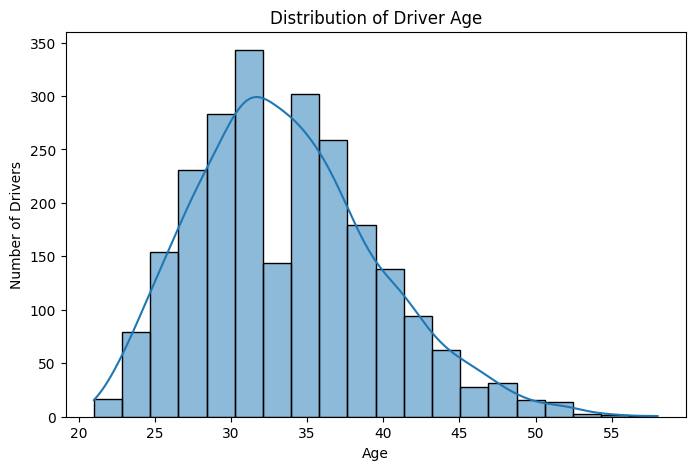

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(driver_df["Age"], bins=20, kde=True)

plt.title("Distribution of Driver Age")
plt.xlabel("Age")
plt.ylabel("Number of Drivers")
plt.savefig("../images/distrivution_driver_age.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Most drivers belong to the middle-age group.
- Extremely young and older drivers are comparatively fewer.

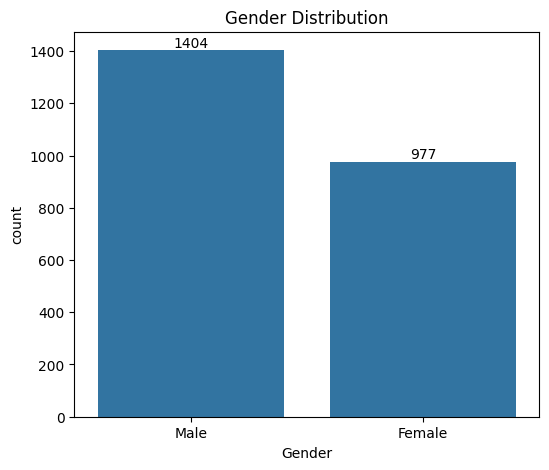

In [32]:
# Gender Distribution
plt.figure(figsize=(6,5))

ax = sns.countplot(data=driver_df, x="Gender")

plt.title("Gender Distribution")

ax.set_xticklabels(["Male", "Female"])

for container in ax.containers:
    ax.bar_label(container)
plt.savefig("../images/gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The dataset is dominated by male drivers.
- Female driver participation is comparatively lower.

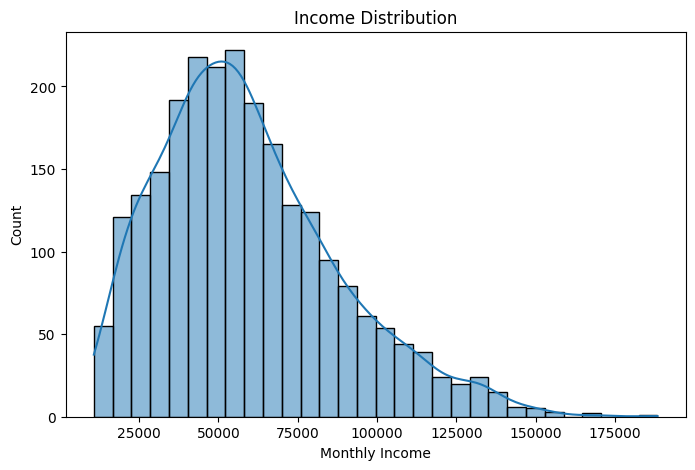

In [33]:
# Income Distribution
plt.figure(figsize=(8,5))

sns.histplot(driver_df["Income"], bins=30, kde=True)

plt.title("Income Distribution")

plt.xlabel("Monthly Income")
plt.savefig("../images/income_Distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Driver income is positively skewed.
- Most drivers fall within a specific income range, while a few drivers earn significantly higher incomes.

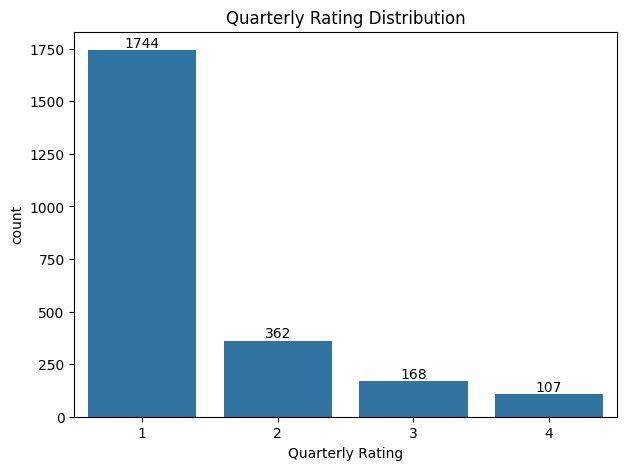

In [34]:
# Quarterly Rating Distribution
plt.figure(figsize=(7,5))

ax = sns.countplot(data=driver_df, x="Quarterly Rating")

plt.title("Quarterly Rating Distribution")

for container in ax.containers:
    ax.bar_label(container)
plt.savefig("../images/quartely_rating_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Most drivers have average quarterly ratings.
- Very high ratings are comparatively less common.

## 6. Attrition by Gender

This analysis examines whether driver attrition differs between male and female drivers.

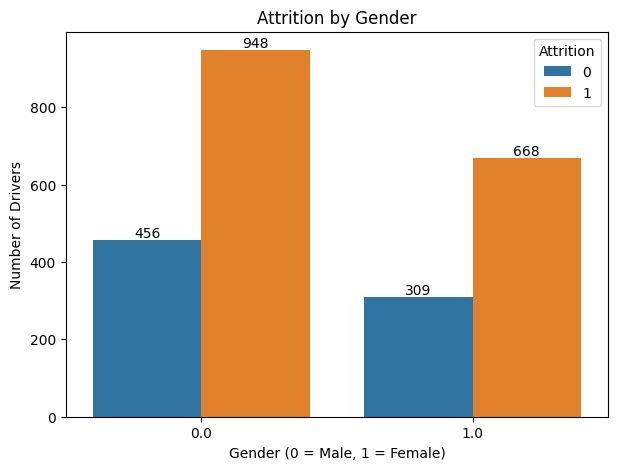

In [35]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=driver_df, x="Gender", hue="Attrition")

plt.title("Attrition by Gender")
plt.xlabel("Gender (0 = Male, 1 = Female)")
plt.ylabel("Number of Drivers")

for container in ax.containers:
    ax.bar_label(container)
plt.savefig("../images/attrition_gender.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Compare attrition rates between male and female drivers.
- If one gender shows a noticeably higher attrition rate, targeted retention strategies can be developed.

## 7. Attrition by Education Level

This analysis evaluates whether educational qualification has any relationship with driver attrition.

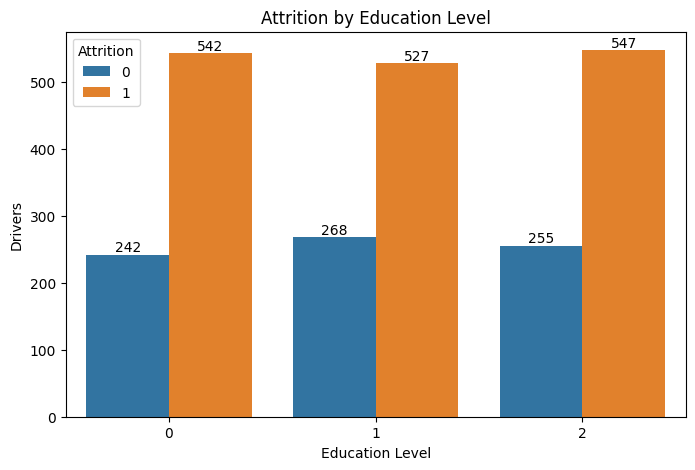

In [36]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=driver_df,
                   x="Education_Level",
                   hue="Attrition")

plt.title("Attrition by Education Level")

plt.xlabel("Education Level")
plt.ylabel("Drivers")

for container in ax.containers:
    ax.bar_label(container)
plt.savefig("../images/attrition_education_level.png", dpi=300, bbox_inches="tight")

plt.show()

## 8. Attrition vs Income Growth

This analysis examines whether drivers who received an income increase are more likely to remain with the company.

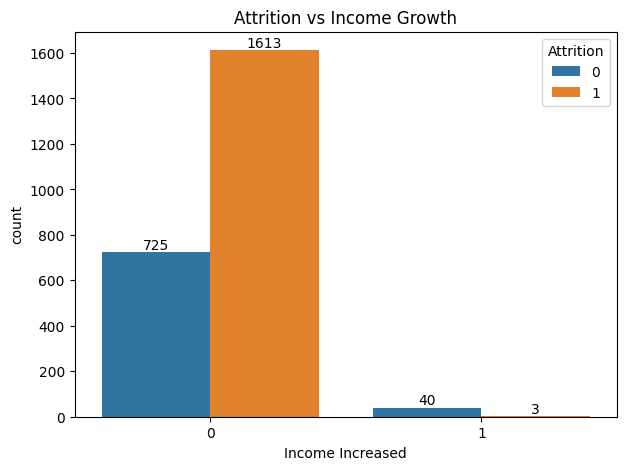

In [37]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=driver_df,
                   x="Income_Increased",
                   hue="Attrition")

plt.title("Attrition vs Income Growth")

plt.xlabel("Income Increased")

for container in ax.containers:
    ax.bar_label(container)
plt.savefig("../images/attrition_vs_income_growth.png", dpi=300, bbox_inches="tight")

plt.show()

EDA 9: Attrition by Rating Improvement


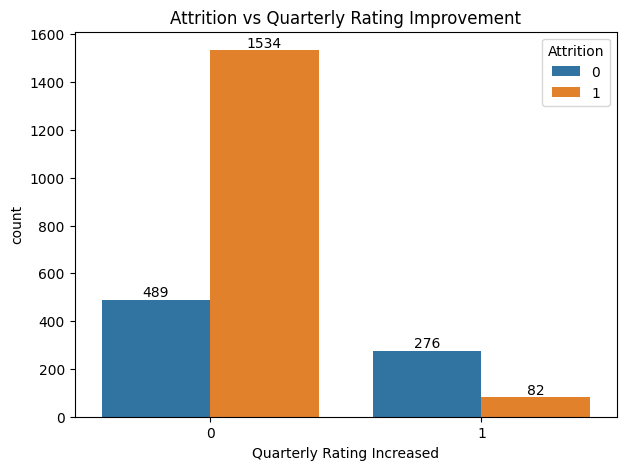

In [38]:

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=driver_df,
    x="Quarterly_Rating_Increased",
    hue="Attrition"
)

plt.title("Attrition vs Quarterly Rating Improvement")

plt.xlabel("Quarterly Rating Increased")

for container in ax.containers:
    ax.bar_label(container)
plt.savefig("../images/attrition_vs_quartely_rating_improvement.png", dpi=300, bbox_inches="tight")

plt.show()

## 10. Driver Tenure vs Attrition

This visualization compares the tenure of active and inactive drivers.

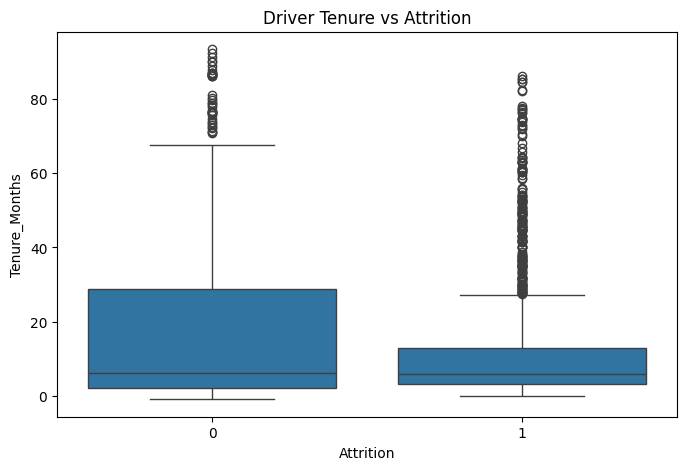

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=driver_df,
    x="Attrition",
    y="Tenure_Months"
)

plt.title("Driver Tenure vs Attrition")
plt.savefig("../images/driver_tenure_vs_attrition.png", dpi=300, bbox_inches="tight")

plt.show()

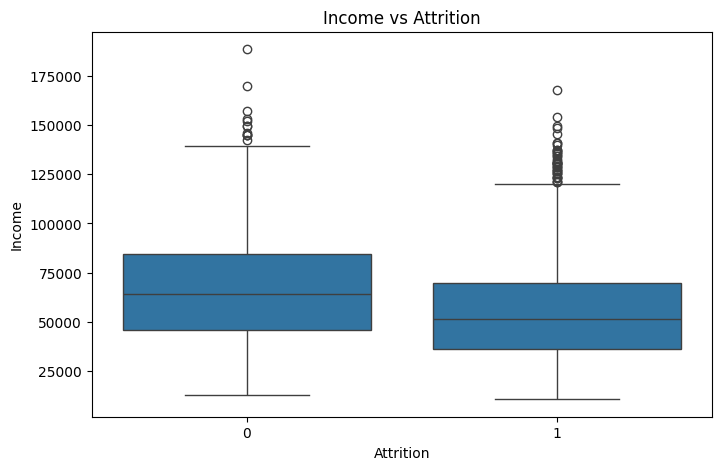

In [40]:
# EDA 11: Income vs Attrition
plt.figure(figsize=(8,5))

sns.boxplot(
    data=driver_df,
    x="Attrition",
    y="Income"
)

plt.title("Income vs Attrition")
plt.savefig("../images/income_vs_attrition.png", dpi=300, bbox_inches="tight")

plt.show()

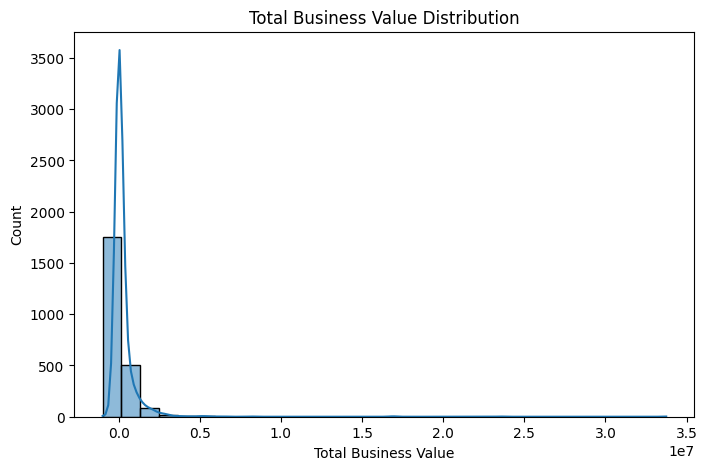

In [41]:
# EDA 12: Business Value Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    driver_df["Total Business Value"],
    bins=30,
    kde=True
)

plt.title("Total Business Value Distribution")
plt.savefig("../images/total_business_value_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


### Observation

- The heatmap highlights the correlation between numerical features.
- Strong positive correlations indicate variables moving together.
- Negative correlations indicate inverse relationships.
- Attrition-related features can be analyzed to understand key drivers of employee turnover.

# Key Business Insights

Based on the exploratory data analysis, the following insights were identified:

1. Driver attrition is concentrated within specific driver segments.
2. Income growth appears to influence driver retention.
3. Drivers with improved quarterly ratings tend to have better retention.
4. Short-tenure drivers are more likely to leave the company.
5. Business value generated by drivers varies significantly across the workforce.

# Correlation Analysis

## Overview

Correlation analysis helps identify the strength and direction of relationships between numerical variables. It provides valuable insights into how different factors are associated with driver attrition and overall business performance.

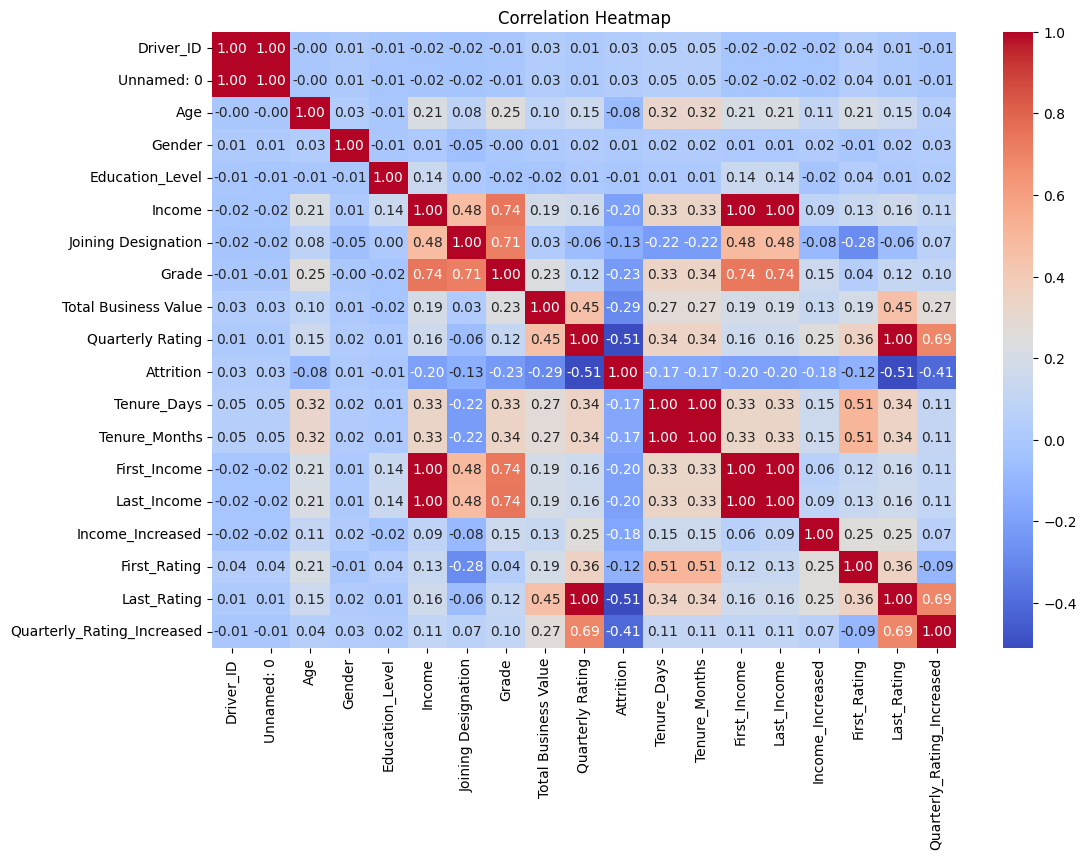

In [42]:
plt.figure(figsize=(12,8))

correlation = driver_df.select_dtypes(include=["number"]).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("../images/correlation.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- The heatmap highlights the correlation between numerical features.
- Strong positive correlations indicate variables moving together.
- Negative correlations indicate inverse relationships.
- Attrition-related features can be analyzed to understand key drivers of employee turnover.

# Final Dataset Overview

The dataset has been successfully cleaned and transformed. New features have been engineered to support business analysis and improve the understanding of driver attrition.

In [43]:
driver_df.head()
driver_df.info()
driver_df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 2381 entries, 0 to 2380
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Driver_ID                   2381 non-null   int64         
 1   Unnamed: 0                  2381 non-null   int64         
 2   MMM-YY                      2381 non-null   datetime64[us]
 3   Age                         2381 non-null   float64       
 4   Gender                      2381 non-null   float64       
 5   City                        2381 non-null   str           
 6   Education_Level             2381 non-null   int64         
 7   Income                      2381 non-null   int64         
 8   Dateofjoining               2381 non-null   datetime64[us]
 9   LastWorkingDate             1616 non-null   datetime64[us]
 10  Joining Designation         2381 non-null   int64         
 11  Grade                       2381 non-null   int64         
 12  Tot

,count,mean,min,25%,50%,75%,max,std
Driver_ID,2381.0,1397.559009,1.0,695.0,1400.0,2100.0,2788.0,806.161628
Unnamed: 0,2381.0,9431.553969,2.0,4644.0,9438.0,14071.0,19103.0,5482.38915
MMM-YY,2381,2020-03-31 15:04:09.475010,2019-01-01 00:00:00,2019-09-01 00:00:00,2020-06-01 00:00:00,2020-12-01 00:00:00,2020-12-01 00:00:00,NaN
Age,2381.0,33.663167,21.0,29.0,33.0,37.0,58.0,5.983375
Gender,2381.0,0.410332,0.0,0.0,0.0,1.0,1.0,0.491997
Education_Level,2381.0,1.00756,0.0,0.0,1.0,2.0,2.0,0.81629
Income,2381.0,59334.157077,10747.0,39104.0,55315.0,75986.0,188418.0,28383.666384
Dateofjoining,2381,2019-02-08 07:14:50.550189,2013-04-01 00:00:00,2018-06-29 00:00:00,2019-07-21 00:00:00,2020-05-02 00:00:00,2020-12-28 00:00:00,NaN
LastWorkingDate,1616,2019-12-21 20:59:06.534653,2018-12-31 00:00:00,2019-06-06 00:00:00,2019-12-20 12:00:00,2020-07-03 00:00:00,2020-12-28 00:00:00,NaN
Joining Designation,2381.0,1.820244,1.0,1.0,2.0,2.0,5.0,0.841433


# Business Recommendations

Based on the analysis, the following recommendations can help reduce driver attrition:

### 1. Improve Driver Retention
- Identify drivers with shorter tenure and provide onboarding support.

### 2. Performance-Based Incentives
- Reward drivers with consistently high quarterly ratings.

### 3. Salary & Incentive Review
- Offer timely income revisions and performance bonuses.

### 4. Early Attrition Monitoring
- Build an early warning system to identify drivers at risk of leaving.

### 5. Training Programs
- Support low-performing drivers through coaching and mentoring.

### 6. Promotion Opportunities
- Recognize high-performing drivers with career growth opportunities.

# Conclusion

This project analyzed Ola's driver dataset to understand the factors influencing driver attrition.

Key preprocessing tasks included handling missing values, feature engineering, and creating a driver-level dataset. Exploratory Data Analysis revealed patterns related to driver demographics, tenure, income, quarterly ratings, and business value.

The insights generated from this analysis can help Ola design targeted retention strategies, improve driver engagement, and reduce recruitment costs.